In [1]:
import s3fs
import xarray as xr
import boto3
import gsw
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import matplotlib.patches as mpatches
import cmocean
import os
import glob
import imageio
import subprocess
import numpy as np
from tqdm import tqdm

In [2]:
def convert_lons(da, dim='lon'):
    da.coords[dim] = (((360 + (da[dim] % 360)) % 360))
    da_new_lon = da.sortby(da[dim])
    return da_new_lon

In [33]:
def match_climo_float(filepath_name, GOBAI_varname, float_varname):
    
    s3_path = "s3://uw-escience-scratch-prod/team_mhw/"

    # Open z-axis interpolated float data
    ds_float = xr.open_zarr(s3_path+'regridded_floats/swp_regridded_profiles_full.zarr').compute()
    ds_float = convert_lons(ds_float, dim='LONGITUDE')

    # Start with the original float dataset
    ds_float_all = ds_float.copy()
    
    for i in tqdm(range(len(GOBAI_varname))):
        # Open z-axis interpolated data product
        ds_GOBAI = xr.open_dataset(
            s3_path + filepath_name[i] + '_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc',
            engine="h5netcdf"
        )
        da_GOBAI = ds_GOBAI[GOBAI_varname[i]].sel(lat=slice(-60, -40), lon=slice(150, 220))

        # Read in float variable
        float_profiles = ds_float[float_varname[i]]
        
        # Calculate climatology values matched to nearest float profile location
        matched_climo = da_GOBAI.sel(
            lat=float_profiles['LATITUDE'].values,
            lon=float_profiles['LONGITUDE'].values,
            month=float_profiles['JULD'].dt.month.values,
            method='nearest'
        ).compute()
    
        # Create descriptive name: e.g., "ABS_SAL_CLIMO"
        matched_climo.name = float_varname[i] + '_CLIMO'
        
        # Merge into accumulated dataset
        ds_float_all = xr.merge([ds_float_all, matched_climo])
    
    # Save to zarr
    ds_float_all.to_zarr(s3_path + 'regridded_floats/swp_regridded_profiles_with_matched_climo.zarr', mode='w')

    return ds_float_all



In [34]:
filepath_name = ['RG09_potential_temperature','RG09_absolute_salinity','GOBAI-O2-v2.3_oxygen','GOBAI-O2-v2.3_oxysat','GOBAI-O2-v2.3_AOU']
GOBAI_varname = ['temp','sal','oxy','oxysat','AOU']
float_varname = ['POTENTIAL_TEMP','ABS_SAL','DOXY','O2_SATURATION','AOU']

match_climo_float(filepath_name, GOBAI_varname, float_varname)

  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
filepath_name = ['potential_temperature','absolute_salinity','oxygen','oxysat','AOU']
GOBAI_varname = ['temp','sal','oxy','oxysat','AOU']
float_varname = ['POTENTIAL_TEMP','ABS_SAL','DOXY','O2_SATURATION','AOU']

def match_climo_float(filepath_name, GOBAI_varname, float_varname):
    
    s3_path = "s3://uw-escience-scratch-prod/team_mhw/"

    #open z-axis interpolated float data
    ds_float = xr.open_zarr(s3_path+'regridded_floats/swp_regridded_profiles_full.zarr').compute()
    ds_float = convert_lons(ds_float,dim='LONGITUDE')

    matched_var = []
    
    for i in range(len(GOBAI_varname)):
        #open z-axis interpolated data product
        ds_GOBAI = xr.open_dataset(s3_path+filepath_varname+'_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc', engine="h5netcdf")
        da_GOBAI = ds_GOBAI[GOBAI_varname].sel(lat = slice(-60,-40),lon = slice(150,220))

        #read in float variable
        float_profiles = ds_float[float_varname]
        
        #calculate climatology values matched to nearest float profile location
        matched_climo = da_GOBAI.sel(lat=float_profiles['LATITUDE'],
                           lon=float_profiles['LONGITUDE'],
                           month=float_profiles['JULD'].dt.month,
                           method='nearest').compute()
    
        matched_climo.name = float_varname + '_CLIMO'
        ds_float_all = xr.merge([ds_float, matched_climo])

    # save output with matched climo variable
    
    # mask for mhw and non-mhw (do this afterwards) ---------
    
    # open SW Pacific MHW mask
    # mhw_swp_mask = xr.open_zarr(f's3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr').compute()
    
    

In [11]:
s3_path = "s3://uw-escience-scratch-prod/team_mhw/"
#open GOBAI climatology
GOBAI_varname = 'temp'
float_varname = 'TEMP'
filepath_varname = 'RG09_potential_temperature'
ds_GOBAI = xr.open_dataset(s3_path+filepath_varname+'_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc', engine="h5netcdf")
da_GOBAI = ds_GOBAI[GOBAI_varname].sel(lat = slice(-60,-40),lon = slice(150,220))

#open interpolated float data
ds_float = xr.open_zarr(s3_path+'regridded_floats/swp_regridded_profiles_full.zarr').compute()
ds_float = convert_lons(ds_float,dim='LONGITUDE')
float_profiles = ds_float[float_varname]


In [12]:
# open SWPac MHW mask
mhw_swp_mask = xr.open_zarr(f's3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr').compute()

In [15]:
# float_profiles_180 = xr.open_zarr('s3://uw-escience-scratch-prod/team_mhw/regridded_floats/swp_regridded_profiles_full.zarr').compute()
# float_profiles = convert_lons(float_profiles_180, dim='LONGITUDE')
# da_float = float_profiles[float_varname]

In [13]:
float_profiles_mhw_mask = mhw_swp_mask['mhw_mask'].sel(lat=float_profiles['LATITUDE'],
                                                       lon=float_profiles['LONGITUDE'],
                                                       time=float_profiles['JULD'].dt.date,
                                                       method='nearest')

In [14]:
mhw_float = float_profiles.where(float_profiles_mhw_mask==1, np.nan, drop=True)
non_mhw_float = float_profiles.where(float_profiles_mhw_mask==0, np.nan, drop=True)

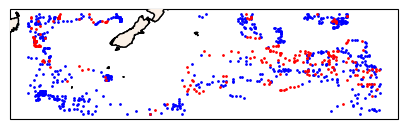

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines(resolution = "50m", zorder=5, linewidth = 1)
ax.add_feature(cfeature.LAND, zorder=5, linewidth = 1, edgecolor='k', facecolor='linen')
# ax.set_global()

ax.scatter(non_mhw_float.lon, non_mhw_float.lat, c='blue', s=1, transform=ccrs.PlateCarree())
ax.scatter(mhw_float.lon, mhw_float.lat, c='r', s=1, transform=ccrs.PlateCarree())
# ax.scatter(float_profiles.LONGITUDE, float_profiles.LATITUDE, c='r', s=1, transform=ccrs.PlateCarree())

plt.show()

In [16]:
matched_climo = da_GOBAI.sel(lat=mhw_float['LATITUDE'],
                       lon=mhw_float['LONGITUDE'],
                       month=mhw_float['JULD'].dt.month,
                       method='nearest').compute()

In [17]:
matched_climo

<xarray.DataArray 'temp' (profile: 243, pres: 1001)> Size: 2MB
array([[17.0830953 , 17.08136818, 17.07964105, ...,  5.32442197,
         5.31791716,  5.31141235],
       [19.63646053, 19.6324178 , 19.62837507, ...,  5.06807986,
         5.06199294,  5.05590602],
       [19.63646053, 19.6324178 , 19.62837507, ...,  5.06807986,
         5.06199294,  5.05590602],
       ...,
       [ 8.27077805,  8.27011784,  8.26945763, ...,  5.12308472,
         5.11696749,  5.11085027],
       [ 6.7402542 ,  6.73947321,  6.73869221, ...,  2.71774188,
         2.71651141,  2.71528093],
       [ 7.86857149,  7.86761604,  7.86666059, ...,  4.55581791,
         4.5503347 ,  4.54485148]], shape=(243, 1001))
Coordinates:
    lon              (profile) float32 972B 150.5 150.5 150.5 ... 219.5 219.5
    lat              (profile) float32 972B -42.5 -40.5 -40.5 ... -54.5 -51.5
    month            (profile) int64 2kB 4 1 1 2 6 6 6 6 ... 9 5 10 3 9 10 3 10
  * pres             (pres) int64 8kB 0 1 2 3 4 5 6 ... 995 996 997 998 999 1000
    CYCLE_NUMBER     (profile) int64 2kB 105 22 23 25 50 51 ... 29 30 32 28 31
    JULD             (profile) datetime64[ns] 2kB 2024-04-15T07:33:00 ... 202...
    LATITUDE         (profile) float64 2kB -42.83 -40.71 ... -54.89 -51.16
    LONGITUDE        (profile) float64 2kB 150.8 150.8 150.8 ... 219.3 219.6
    PLATFORM_NUMBER  (profile) <U7 7kB '5905553' '2903458' ... '5906545'
  * profile          (profile) int64 2kB 239 87 88 90 134 ... 47 568 611 46 610
    time             (profile) datetime64[ns] 2kB 2024-04-15T12:00:00 ... 202...
Attributes:
    long_name:    Potential Temperature
    units:        celcius
    source:       RG09 Argo Climatology, Roemmich & Gilson, 2009
    description:  climatological average (2004-2024),calculated with GSW

In [18]:
float_anom = mhw_float - matched_climo

In [21]:
anom_mean = float_anom.mean(dim='profile')

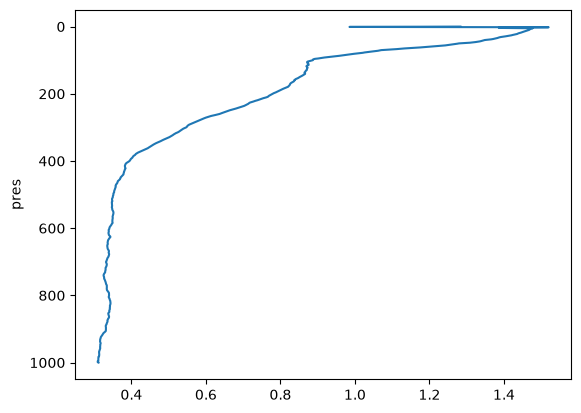

In [24]:
anom_mean.plot(y='pres')
plt.gca().invert_yaxis()